## Imports e setup

In [7]:
import os
import random
from pathlib import Path
from collections import Counter
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk
from scipy.stats import entropy
from utils.drift_detection import plot_image_property_drift

In [3]:
ORIGINAL_DIR = Path("../original_datasets")
PREPROC_DIR = Path("../preprocessed_datasets")
OUT_DIR = Path("../eda_outputs")
OUT_DIR.mkdir(exist_ok=True)
NUM_PROC = max(1, (os.cpu_count() or 1) - 1)
BATCH_SIZE = 128

In [4]:
imagenet_r_raw = load_from_disk(ORIGINAL_DIR / "imagenet_r")
imagenet_1k_raw = load_from_disk(ORIGINAL_DIR / "imagenet-1k")
imagenet_r_pre = load_from_disk(PREPROC_DIR / "imagenet_r_preprocessed")
imagenet_1k_pre = load_from_disk(PREPROC_DIR / "imagenet_1k_preprocessed")

datasets_dict = {
    "ImageNet-R (raw)": imagenet_r_raw,
    "ImageNet-1k val (raw)": imagenet_1k_raw,
    "ImageNet-R (preprocessed)": imagenet_r_pre,
    "ImageNet-1k val (preprocessed, 200 classi)": imagenet_1k_pre,
}

## Analisi esplorativa

### Struttura dei dataset

In [5]:
for name, ds in datasets_dict.items():
    print(f"\n{name}")
    print(ds)


ImageNet-R (raw)
Dataset({
    features: ['image', 'wnid', 'class_name'],
    num_rows: 30000
})

ImageNet-1k val (raw)
Dataset({
    features: ['image', 'label'],
    num_rows: 50000
})

ImageNet-R (preprocessed)
Dataset({
    features: ['image', 'wnid', 'class_name', 'ik_label'],
    num_rows: 30000
})

ImageNet-1k val (preprocessed, 200 classi)
Dataset({
    features: ['image', 'label'],
    num_rows: 10000
})


### Distribuzioni di classe

In [5]:
def class_distribution(dataset, label_col, name):
    """Ritorna una Series con il conteggio di esempi per classe."""
    counts = Counter(dataset[label_col])
    s = pd.Series(counts).sort_index()
    print(f"\n{name}: {len(s)} classi distinte, "
          f"min={s.min()}, max={s.max()}, media={s.mean():.1f}, std={s.std():.1f}")
    return s


ImageNet-R (raw): 200 classi distinte, min=51, max=430, media=150.0, std=72.5

ImageNet-1k preprocessed: 200 classi distinte, min=50, max=50, media=50.0, std=0.0


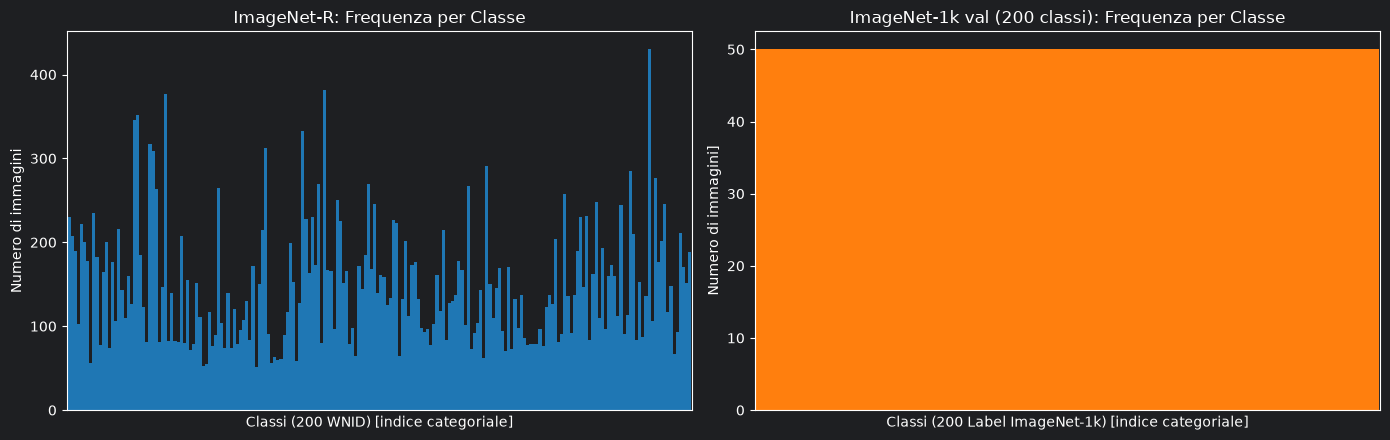

In [6]:
# TODO: Capire come comportarsi, il dataset imagenet_r è molto sbilanciato
r_dist = class_distribution(imagenet_r_raw, "wnid", "ImageNet-R (raw)")
ik_pre_dist = class_distribution(imagenet_1k_pre, "label", "ImageNet-1k preprocessed")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

r_dist.plot(kind="bar", ax=axes[0], width=1.0, color="#1f77b4")
axes[0].set_title("ImageNet-R: Frequenza per Classe")
axes[0].set_xticks([])
axes[0].set_xlabel("Classi (200 WNID) [indice categoriale]")
axes[0].set_ylabel("Numero di immagini")

ik_pre_dist.plot(kind="bar", ax=axes[1], width=1.0, color="#ff7f0e")
axes[1].set_title("ImageNet-1k val (200 classi): Frequenza per Classe")
axes[1].set_xticks([])
axes[1].set_xlabel("Classi (200 Label ImageNet-1k) [indice categoriale]")
axes[1].set_ylabel("Numero di immagini]")

plt.tight_layout()
plt.savefig(OUT_DIR / "class_distribution.png", dpi=150)
plt.show()

#### Overlap delle classi

In [7]:
r_wnids = set(imagenet_r_raw["wnid"])
r_ik_labels = set(imagenet_r_pre["ik_label"])
ik_pre_labels = set(imagenet_1k_pre["label"])
 
print(f"\nWNID distinti in ImageNet-R: {len(r_wnids)}")
print(f"Indici ImageNet-1k coperti da ImageNet-R (via mapping): {len(r_ik_labels)}")
print(f"Indici presenti in ImageNet-1k preprocessato: {len(ik_pre_labels)}")
print(f"Le due liste di indici coincidono esattamente: {r_ik_labels == ik_pre_labels}")

if r_ik_labels != ik_pre_labels:
    print("Differenza:", r_ik_labels.symmetric_difference(ik_pre_labels))



WNID distinti in ImageNet-R: 200
Indici ImageNet-1k coperti da ImageNet-R (via mapping): 200
Indici presenti in ImageNet-1k preprocessato: 200
Le due liste di indici coincidono esattamente: True


#### Proprietà delle immagini

In [15]:
def _image_props_batch(batch, image_col):
    widths, heights, modes = [], [], []
    for img in batch[image_col]:
        widths.append(img.width)
        heights.append(img.height)
        modes.append(img.mode)
    return {"width": widths, "height": heights, "mode": modes}

In [13]:
def full_image_stats(dataset, image_col="image", name=""):
    """Calcola width/height/mode per OGNI immagine del dataset."""
    ds_props = dataset.map(
        _image_props_batch,
        batched=True,
        batch_size=BATCH_SIZE,
        num_proc=NUM_PROC,
        fn_kwargs={"image_col": image_col},
        desc=f"Proprietà immagini - {name}",
    )
    df = ds_props.select_columns(["width", "height", "mode"]).to_pandas()
    print(f"\n{name}: analizzate tutte le {len(df)} immagini")
    print(df[["width", "height"]].describe())
    print("Modalità colore:", dict(Counter(df["mode"])))
    return df


ImageNet-R: analizzate tutte le 30000 immagini
              width        height
count  30000.000000  30000.000000
mean     480.303767    459.184600
std      258.020546    246.666393
min       19.000000     30.000000
25%      374.000000    350.000000
50%      499.000000    441.000000
75%      500.000000    500.000000
max     7016.000000   5833.000000
Modalità colore: {'RGB': 28752, 'L': 1164, 'CMYK': 84}

ImageNet-1k val: analizzate tutte le 10000 immagini
              width        height
count  10000.000000  10000.000000
mean     487.810000    424.156700
std      173.387566    148.992971
min       67.000000     83.000000
25%      450.000000    375.000000
50%      500.000000    375.000000
75%      500.000000    500.000000
max     4048.000000   3072.000000
Modalità colore: {'RGB': 9820, 'L': 180}


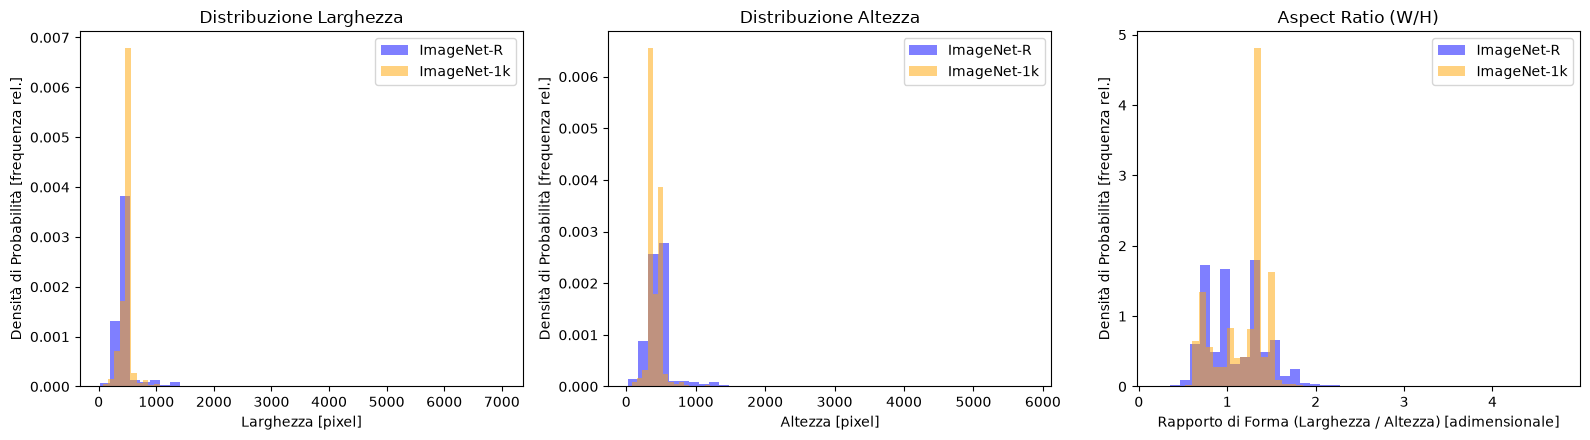

In [16]:
# TODO: Fix e comprendere bene come interpretare correttamente 
r_img_stats = full_image_stats(imagenet_r_raw, name="ImageNet-R")
ik_img_stats = full_image_stats(imagenet_1k_pre, name="ImageNet-1k val")

# Istogrammi sovrapposti (Marginali)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Larghezza [Freq. relativa]
axes[0].hist(r_img_stats["width"], bins=40, alpha=0.5, density=True, label="ImageNet-R", color="blue")
axes[0].hist(ik_img_stats["width"], bins=40, alpha=0.5, density=True, label="ImageNet-1k", color="orange")
axes[0].set_title("Distribuzione Larghezza")
axes[0].set_xlabel("Larghezza [pixel]")
axes[0].set_ylabel("Densità di Probabilità [frequenza rel.]")
axes[0].legend()

# Altezza [Freq. relativa]
axes[1].hist(r_img_stats["height"], bins=40, alpha=0.5, density=True, label="ImageNet-R", color="blue")
axes[1].hist(ik_img_stats["height"], bins=40, alpha=0.5, density=True, label="ImageNet-1k", color="orange")
axes[1].set_title("Distribuzione Altezza")
axes[1].set_xlabel("Altezza [pixel]")
axes[1].set_ylabel("Densità di Probabilità [frequenza rel.]")
axes[1].legend()

# Aspect Ratio
aspect_r = r_img_stats["width"] / r_img_stats["height"]
aspect_ik = ik_img_stats["width"] / ik_img_stats["height"]
axes[2].hist(aspect_r, bins=40, alpha=0.5, density=True, label="ImageNet-R", color="blue")
axes[2].hist(aspect_ik, bins=40, alpha=0.5, density=True, label="ImageNet-1k", color="orange")
axes[2].set_title("Aspect Ratio (W/H)")
axes[2].set_xlabel("Rapporto di Forma (Larghezza / Altezza) [adimensionale]")
axes[2].set_ylabel("Densità di Probabilità [frequenza rel.]")
axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "image_dimensions_distributions.png", dpi=150)
plt.show()

#### Statistiche sui pixel

In [1]:
def _pixel_stats_batch(batch, image_col):
    import numpy as np
    means, stds = [], []
    for img in batch[image_col]:
        arr = np.asarray(img.convert("RGB"), dtype=np.float32) / 255.0
        means.append(arr.mean(axis=(0, 1)))   # media per canale R,G,B
        stds.append(arr.std(axis=(0, 1)))
    means = np.array(means)
    stds = np.array(stds)
    return {
        "mean_r": means[:, 0], "mean_g": means[:, 1], "mean_b": means[:, 2],
        "std_r": stds[:, 0], "std_g": stds[:, 1], "std_b": stds[:, 2],
    }

In [2]:
def full_pixel_stats(dataset, image_col="image", name=""):
    """Calcola media e deviazione standard RGB per OGNI immagine.
    Nota: più lento della versione campionata, perché decodifica ogni
    immagine del dataset — con dataset grandi può richiedere diversi minuti."""
    ds_pix = dataset.map(
        _pixel_stats_batch,
        batched=True,
        batch_size=BATCH_SIZE,
        num_proc=NUM_PROC,
        fn_kwargs={"image_col": image_col},
        desc=f"Statistiche pixel - {name}",
    )
    cols = ["mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b"]
    df = ds_pix.select_columns(cols).to_pandas()
    means = df[["mean_r", "mean_g", "mean_b"]].to_numpy()
    stds = df[["std_r", "std_g", "std_b"]].to_numpy()
    print(f"\n{name} - immagini analizzate: {len(df)}")
    print(f"{name} - media canali RGB: {means.mean(axis=0).round(3)}")
    print(f"{name} - std canali RGB:   {stds.mean(axis=0).round(3)}")
    return means, stds

In [3]:
r_means, r_stds = full_pixel_stats(imagenet_r_raw, name="ImageNet-R")
ik_means, ik_stds = full_pixel_stats(imagenet_1k_pre, name="ImageNet-1k val")

NameError: name 'imagenet_r_raw' is not defined

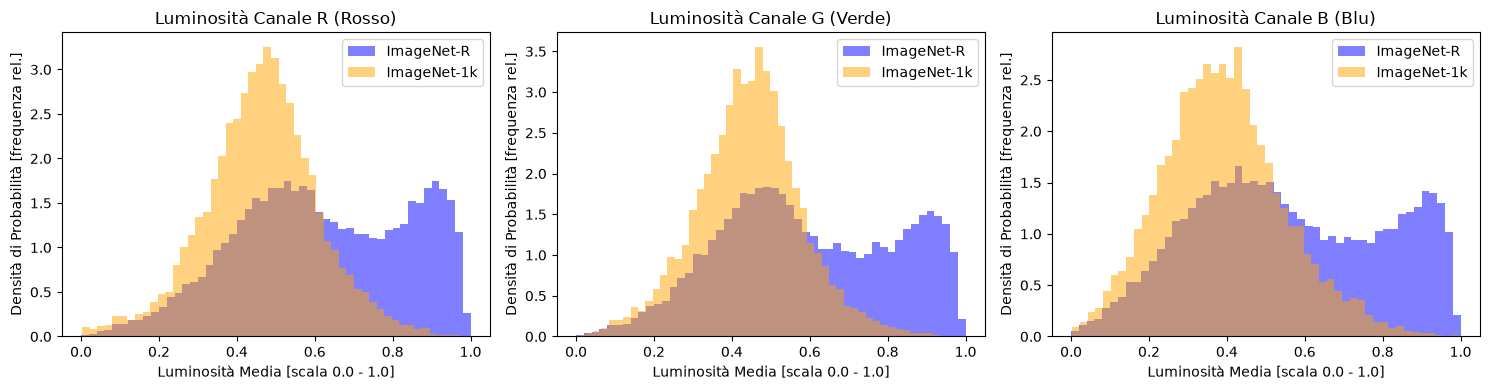


 - immagini analizzate: 30000
 - media canali RGB: [0.62  0.594 0.557]
 - std canali RGB:   [0.231 0.227 0.23 ]


Statistiche pixel -  (num_proc=7):   0%|          | 0/10000 [00:00<?, ? examples/s]

In [23]:
# Grafico 1: Luminosità
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

r_means, r_stds = full_pixel_stats(imagenet_r_pre)
ik_means, ik_stds = full_pixel_stats(imagenet_1k_pre)

channels = ["R (Rosso)", "G (Verde)", "B (Blu)"]
for c, ax in enumerate(axes):
    ax.hist(r_means[:, c], bins=50, alpha=0.5, label="ImageNet-R", density=True, color="blue")
    ax.hist(ik_means[:, c], bins=50, alpha=0.5, label="ImageNet-1k", density=True, color="orange")
    ax.set_title(f"Luminosità Canale {channels[c]}")
    ax.set_xlabel("Luminosità Media [scala 0.0 - 1.0]")
    ax.set_ylabel("Densità di Probabilità [frequenza rel.]")
    ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "pixel_brightness_distribution.png", dpi=150)
plt.show()

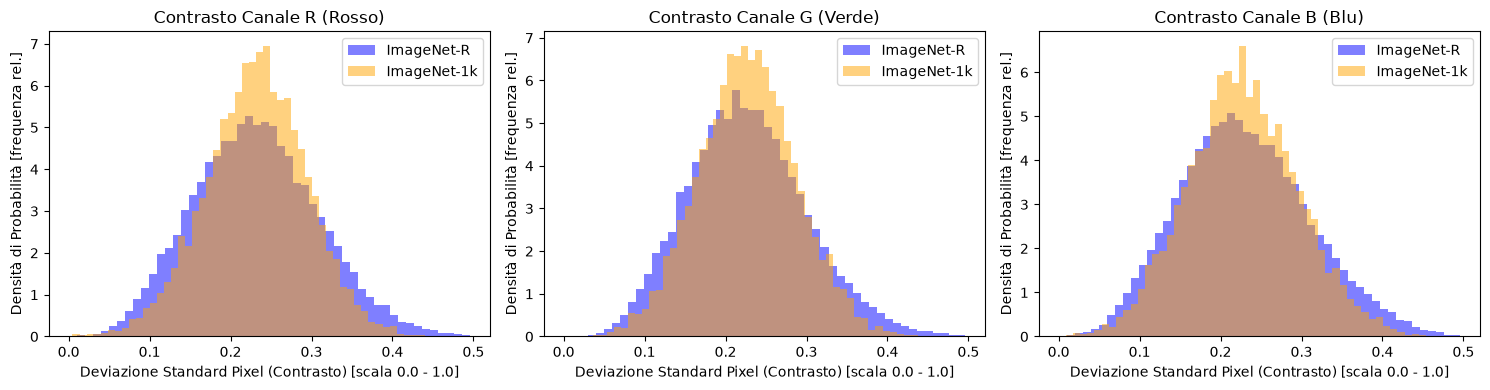

In [24]:
# Grafico 2: Contrasto (Deviazione Standard)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for c, ax in enumerate(axes):
    ax.hist(r_stds[:, c], bins=50, alpha=0.5, label="ImageNet-R", density=True, color="blue")
    ax.hist(ik_stds[:, c], bins=50, alpha=0.5, label="ImageNet-1k", density=True, color="orange")
    ax.set_title(f"Contrasto Canale {channels[c]}")
    ax.set_xlabel("Deviazione Standard Pixel (Contrasto) [scala 0.0 - 1.0]")
    ax.set_ylabel("Densità di Probabilità [frequenza rel.]")
    ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "pixel_contrast_distribution.png", dpi=150)
plt.show()

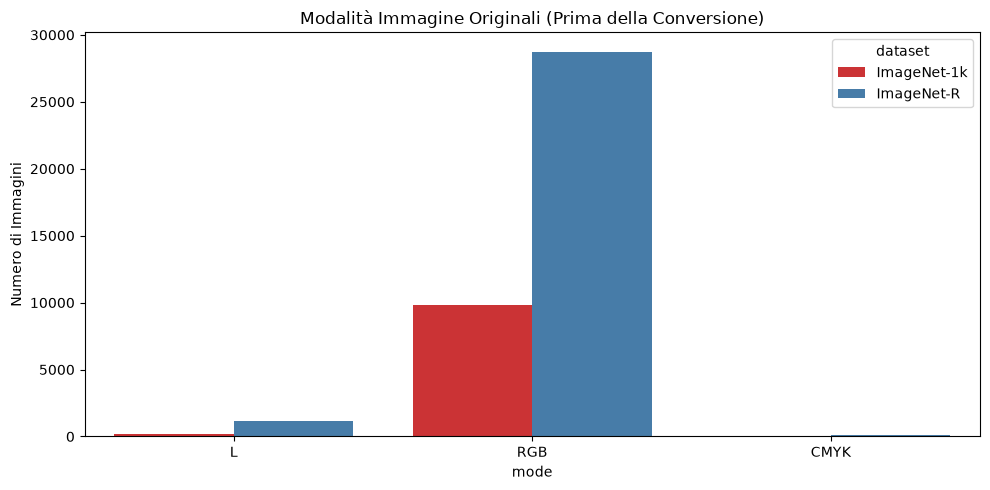

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

ik_img_stats["dataset"] = "ImageNet-1k"
r_img_stats["dataset"] = "ImageNet-R"
df_all = pd.concat([ik_img_stats, r_img_stats], ignore_index=True)

mode_df = df_all.groupby(['dataset', 'mode']).size().reset_index(name='count')
sns.barplot(data=mode_df, x='mode', y='count', hue='dataset', ax=ax, palette="Set1")

ax.set_title("Modalità Immagine Originali (Prima della Conversione)")
ax.set_ylabel("Numero di Immagini")

plt.tight_layout()
plt.show()

ImageNet-1k (pre):   0%|          | 0/10000 [00:00<?, ?it/s]

ImageNet-R (pre):   0%|          | 0/30000 [00:00<?, ?it/s]

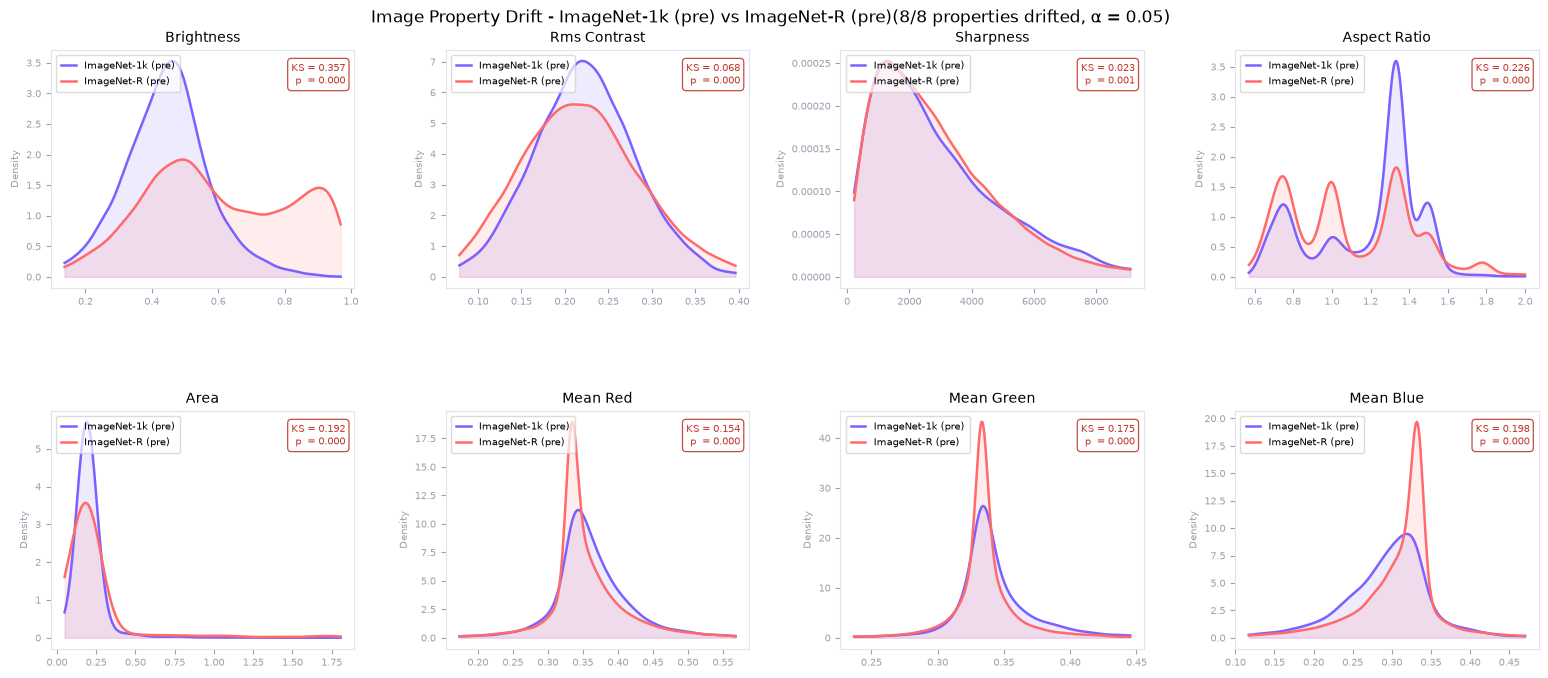

In [6]:
ks_pre = plot_image_property_drift(
    dataset_a   = imagenet_1k_pre,
    dataset_b   = imagenet_r_pre,
    label_a     = "ImageNet-1k (pre)",
    label_b     = "ImageNet-R (pre)",
)

In [35]:
display(ks_pre)

,KS Statistic,p-value,Drift
Property,,,
Brightness,0.428,0.0000,yes
Rms Contrast,0.074,0.1294,no
Sharpness,0.166,0.0000,yes
Aspect Ratio,0.200,0.0000,yes
Area,0.174,0.0000,yes
Mean Red,0.148,0.0000,yes
Mean Green,0.214,0.0000,yes
Mean Blue,0.200,0.0000,yes
